# Lumbar MRI Classification — Modular Pipeline

This notebook implements a modular workflow for **lumbar spine MRI classification** with:

- preprocessing steps aligned with your diagram:
  - image resize
  - noise reduction
  - standardized pixel intensity ranges
  - data augmentation
- class imbalance handling:
  - weighted sampler
  - weighted cross-entropy
  - focal loss
- regularization:
  - augmentation
  - dropout in the classifier head
  - weight decay
  - label smoothing
  - random erasing
  - optional MixUp
  - early stopping
- model families:
  - VGG
  - ResNet
  - DenseNet
  - EfficientNet
  - Vision Transformer (ViT)
  - Swin Transformer

It also fixes AMP deprecation by using `torch.amp.autocast(...)` instead of `torch.cuda.amp.autocast(...)`.

In [17]:
# =========================
# 1) Imports
# =========================
import os
import re
import copy
import time
import math
import json
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from torchvision.transforms import InterpolationMode

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.6.0+cu124
CUDA available: True


In [18]:
# =========================
# 2) Reproducibility
# =========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

In [19]:
# =========================
# 3) Config
# =========================
@dataclass
class CFG:
    # ---- paths ----
    DATA_ROOT: str = "/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-classification"
    TRAIN_DIR_NAME: str = "train"
    TEST_DIR_NAME: str = "test"

    # ---- split ----
    TRAIN_RATIO: float = 0.80
    GAP_BETWEEN_SPLITS: int = 10  # blocked split buffer if you only have slice ids

    # ---- image ----
    IMAGE_SIZE: int = 224
    RESIZE_SIZE: int = 256
    IN_CHANNELS: int = 1

    # preprocessing controls
    USE_NOISE_REDUCTION: bool = True
    NOISE_REDUCTION_MODE: str = "gaussian"  # gaussian | median | none
    GAUSSIAN_BLUR_RADIUS: float = 0.6
    MEDIAN_FILTER_SIZE: int = 3

    USE_INTENSITY_STANDARDIZATION: bool = True
    INTENSITY_CLIP_PERCENTILES: tuple = (1.0, 99.0)
    STANDARDIZATION_MODE: str = "zscore"  # zscore | minmax

    # ---- augmentation ----
    USE_AUGMENTATION: bool = True
    AUG_ROTATION_DEG: float = 7.0
    AUG_TRANSLATE: tuple = (0.03, 0.03)
    AUG_SCALE: tuple = (0.95, 1.05)
    AUG_CROP_SCALE: tuple = (0.90, 1.00)
    AUG_CROP_RATIO: tuple = (0.95, 1.05)
    AUG_BRIGHTNESS: float = 0.10
    AUG_CONTRAST: float = 0.10
    AUG_RANDOM_ERASE_P: float = 0.10

    # ---- model ----
    MODEL_FAMILY: str = "resnet"   # vgg | resnet | densenet | efficientnet | vit | swin
    MODEL_NAME: str = "resnet34"   # see builders below
    PRETRAINED: bool = True
    HEAD_DROPOUT: float = 0.30

    # ---- optimization ----
    BATCH_SIZE: int = 32
    NUM_WORKERS: int = 2
    EPOCHS: int = 30
    LR: float = 3e-4
    WEIGHT_DECAY: float = 1e-4

    # ---- regularization ----
    LABEL_SMOOTHING: float = 0.05
    USE_MIXUP: bool = False
    MIXUP_ALPHA: float = 0.20
    FREEZE_BACKBONE_EPOCHS: int = 0

    # ---- imbalance handling ----
    USE_WEIGHTED_SAMPLER: bool = True
    USE_CLASS_WEIGHTS_IN_LOSS: bool = False
    LOSS_NAME: str = "ce"  # ce | focal
    FOCAL_GAMMA: float = 2.0

    # ---- normalization ----
    # If None, compute from train split.
    TRAIN_MEAN: float | None = None
    TRAIN_STD: float | None = None
    MEAN_STD_SAMPLES: int = 500

    # ---- early stopping ----
    EARLY_STOPPING_PATIENCE: int = 5
    EARLY_STOPPING_MIN_DELTA: float = 1e-4

    # ---- misc ----
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    AMP: bool = True
    SAVE_DIR: str = "./runs_modular_mri"

cfg = CFG()
os.makedirs(cfg.SAVE_DIR, exist_ok=True)
print(cfg)

CFG(DATA_ROOT='/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-classification', TRAIN_DIR_NAME='train', TEST_DIR_NAME='test', TRAIN_RATIO=0.8, GAP_BETWEEN_SPLITS=10, IMAGE_SIZE=224, RESIZE_SIZE=256, IN_CHANNELS=1, USE_NOISE_REDUCTION=True, NOISE_REDUCTION_MODE='gaussian', GAUSSIAN_BLUR_RADIUS=0.6, MEDIAN_FILTER_SIZE=3, USE_INTENSITY_STANDARDIZATION=True, INTENSITY_CLIP_PERCENTILES=(1.0, 99.0), STANDARDIZATION_MODE='zscore', USE_AUGMENTATION=True, AUG_ROTATION_DEG=7.0, AUG_TRANSLATE=(0.03, 0.03), AUG_SCALE=(0.95, 1.05), AUG_CROP_SCALE=(0.9, 1.0), AUG_CROP_RATIO=(0.95, 1.05), AUG_BRIGHTNESS=0.1, AUG_CONTRAST=0.1, AUG_RANDOM_ERASE_P=0.1, MODEL_FAMILY='resnet', MODEL_NAME='resnet34', PRETRAINED=True, HEAD_DROPOUT=0.3, BATCH_SIZE=32, NUM_WORKERS=2, EPOCHS=30, LR=0.0003, WEIGHT_DECAY=0.0001, LABEL_SMOOTHING=0.05, USE_MIXUP=False, MIXUP_ALPHA=0.2, FREEZE_BACKBONE_EPOCHS=0, USE_WEIGHTED_SAMPLER=True, USE_CLASS_WEIGHTS_IN_LOSS=False, LOSS_NA

In [20]:
# =========================
# 4) Paths and metadata
# =========================
TRAIN_DIR = Path(cfg.DATA_ROOT) / cfg.TRAIN_DIR_NAME
TEST_DIR = Path(cfg.DATA_ROOT) / cfg.TEST_DIR_NAME

assert TRAIN_DIR.exists(), f"Train dir not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Test dir not found: {TEST_DIR}"

def extract_num(fname: str):
    m = re.search(r"image_(\d+)\.jpg$", fname)
    return int(m.group(1)) if m else None

def collect_records(split_dir: Path):
    records = []
    for cls_name in sorted([d.name for d in split_dir.iterdir() if d.is_dir()]):
        class_dir = split_dir / cls_name
        for path in sorted(class_dir.glob("*.jpg")):
            records.append({
                "path": str(path),
                "label": cls_name,
                "num_id": extract_num(path.name),
                "file_name": path.name,
            })
    df = pd.DataFrame(records)
    if len(df) == 0:
        raise ValueError(f"No images found in {split_dir}")
    return df

full_train_df = collect_records(TRAIN_DIR)
test_df = collect_records(TEST_DIR)

CLASS_NAMES = sorted(full_train_df["label"].unique().tolist())
label2id = {c: i for i, c in enumerate(CLASS_NAMES)}
id2label = {i: c for c, i in label2id.items()}

full_train_df["label_id"] = full_train_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

print("Class names:", CLASS_NAMES)
print("Train size:", len(full_train_df))
print("Test size:", len(test_df))
display(full_train_df.head())

Class names: ['Herniated Disc', 'No Stenosis', 'Thecal Sac']
Train size: 10948
Test size: 2738


,path,label,num_id,file_name,label_id
0,/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesi...,Herniated Disc,10059,image_10059.jpg,0
1,/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesi...,Herniated Disc,10060,image_10060.jpg,0
2,/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesi...,Herniated Disc,10061,image_10061.jpg,0
3,/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesi...,Herniated Disc,10062,image_10062.jpg,0
4,/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesi...,Herniated Disc,10063,image_10063.jpg,0


In [21]:
# =========================
# 5) Blocked split helper
# =========================
# If you later obtain patient_id or study_id, replace this with GroupKFold / GroupShuffleSplit.

def blocked_train_val_split_per_class(df: pd.DataFrame, train_ratio: float = 0.8, gap: int = 10):
    train_parts, val_parts = [], []

    for cls, sub in df.groupby("label"):
        sub = sub.sort_values(["num_id", "file_name"]).reset_index(drop=True)
        n = len(sub)
        train_end = int(n * train_ratio)
        val_start = min(n, train_end + gap)

        train_parts.append(sub.iloc[:train_end].copy())
        val_parts.append(sub.iloc[val_start:].copy())

    train_df = pd.concat(train_parts, axis=0).sample(frac=1.0, random_state=42).reset_index(drop=True)
    val_df = pd.concat(val_parts, axis=0).sample(frac=1.0, random_state=42).reset_index(drop=True)
    return train_df, val_df

train_df, val_df = blocked_train_val_split_per_class(
    full_train_df,
    train_ratio=cfg.TRAIN_RATIO,
    gap=cfg.GAP_BETWEEN_SPLITS
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print(train_df["label"].value_counts().sort_index())

Train: 8757 Val: 2161 Test: 2738
label
Herniated Disc    2450
No Stenosis       2521
Thecal Sac        3786
Name: count, dtype: int64


In [22]:
# =========================
# 6) Preprocessing utilities
# =========================
class NoiseReduction:
    """
    PIL -> PIL
    Mild denoising only. Avoid aggressive filtering in MRI.
    """
    def __init__(self, mode="gaussian", gaussian_radius=0.6, median_size=3):
        self.mode = mode
        self.gaussian_radius = gaussian_radius
        self.median_size = median_size

    def __call__(self, img: Image.Image):
        if self.mode == "none":
            return img
        if self.mode == "gaussian":
            return img.filter(ImageFilter.GaussianBlur(radius=self.gaussian_radius))
        if self.mode == "median":
            # PIL MedianFilter size should be odd
            size = int(self.median_size)
            if size % 2 == 0:
                size += 1
            return img.filter(ImageFilter.MedianFilter(size=size))
        raise ValueError(f"Unknown noise reduction mode: {self.mode}")


class StandardizeIntensity:
    """
    PIL -> PIL
    Standardizes grayscale intensities after percentile clipping.
    Returns 8-bit PIL image so the rest of torchvision pipelines stay simple.
    """
    def __init__(self, clip_percentiles=(1.0, 99.0), mode="zscore"):
        self.clip_percentiles = clip_percentiles
        self.mode = mode

    def __call__(self, img: Image.Image):
        x = np.asarray(img).astype(np.float32)

        p_low, p_high = np.percentile(x, self.clip_percentiles)
        x = np.clip(x, p_low, p_high)

        if self.mode == "zscore":
            mean = x.mean()
            std = x.std()
            std = std if std > 1e-6 else 1.0
            x = (x - mean) / std
            # map back to [0, 255] for PIL compatibility
            x = (x - x.min()) / max(x.max() - x.min(), 1e-6)
            x = (x * 255.0).clip(0, 255).astype(np.uint8)
        elif self.mode == "minmax":
            x = (x - x.min()) / max(x.max() - x.min(), 1e-6)
            x = (x * 255.0).clip(0, 255).astype(np.uint8)
        else:
            raise ValueError(f"Unknown standardization mode: {self.mode}")

        return Image.fromarray(x, mode="L")


def compute_mean_std_from_paths(paths, n_samples=None):
    if n_samples is not None:
        paths = random.sample(list(paths), min(n_samples, len(paths)))

    total_sum = 0.0
    total_sq_sum = 0.0
    total_pixels = 0

    for path in paths:
        img = np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0
        total_sum += img.sum()
        total_sq_sum += (img ** 2).sum()
        total_pixels += img.size

    mean = total_sum / total_pixels
    var = total_sq_sum / total_pixels - mean ** 2
    std = max(var, 1e-12) ** 0.5
    return float(mean), float(std)

In [23]:
# =========================
# 7) Compute normalization stats (train only)
# =========================
if cfg.TRAIN_MEAN is None or cfg.TRAIN_STD is None:
    train_mean, train_std = compute_mean_std_from_paths(
        train_df["path"].tolist(),
        n_samples=cfg.MEAN_STD_SAMPLES
    )
else:
    train_mean, train_std = cfg.TRAIN_MEAN, cfg.TRAIN_STD

print("Train mean:", train_mean)
print("Train std :", train_std)

Train mean: 0.19263936579227448
Train std : 0.25802746415138245


In [24]:
# =========================
# 8) Build preprocessing + augmentation transforms
# =========================
def build_pre_tensor_pipeline(cfg: CFG, is_train: bool):
    ops = []

    # 1) image resize / geometry standardization
    ops.append(transforms.Resize((cfg.RESIZE_SIZE, cfg.RESIZE_SIZE), interpolation=InterpolationMode.BILINEAR))

    # 2) noise reduction
    if cfg.USE_NOISE_REDUCTION and cfg.NOISE_REDUCTION_MODE != "none":
        ops.append(NoiseReduction(
            mode=cfg.NOISE_REDUCTION_MODE,
            gaussian_radius=cfg.GAUSSIAN_BLUR_RADIUS,
            median_size=cfg.MEDIAN_FILTER_SIZE
        ))

    # 3) standardized pixel intensity ranges
    if cfg.USE_INTENSITY_STANDARDIZATION:
        ops.append(StandardizeIntensity(
            clip_percentiles=cfg.INTENSITY_CLIP_PERCENTILES,
            mode=cfg.STANDARDIZATION_MODE
        ))

    # 4) augmentation (train only)
    if is_train and cfg.USE_AUGMENTATION:
        ops.extend([
            transforms.RandomResizedCrop(
                size=cfg.IMAGE_SIZE,
                scale=cfg.AUG_CROP_SCALE,
                ratio=cfg.AUG_CROP_RATIO,
                interpolation=InterpolationMode.BILINEAR,
            ),
            transforms.RandomRotation(cfg.AUG_ROTATION_DEG, interpolation=InterpolationMode.BILINEAR),
            transforms.RandomAffine(
                degrees=0,
                translate=cfg.AUG_TRANSLATE,
                scale=cfg.AUG_SCALE,
                interpolation=InterpolationMode.BILINEAR,
            ),
            transforms.ColorJitter(
                brightness=cfg.AUG_BRIGHTNESS,
                contrast=cfg.AUG_CONTRAST
            ),
        ])
    else:
        ops.append(transforms.CenterCrop(cfg.IMAGE_SIZE))

    return transforms.Compose(ops)


def build_post_tensor_pipeline(mean: float, std: float, is_train: bool, cfg: CFG):
    ops = [
        transforms.ToTensor(),
        transforms.Normalize(mean=[mean], std=[std]),
    ]

    if is_train and cfg.USE_AUGMENTATION and cfg.AUG_RANDOM_ERASE_P > 0:
        ops.append(
            transforms.RandomErasing(
                p=cfg.AUG_RANDOM_ERASE_P,
                scale=(0.01, 0.04),
                ratio=(0.7, 1.3),
                value="random"
            )
        )
    return transforms.Compose(ops)


train_pre_tf = build_pre_tensor_pipeline(cfg, is_train=True)
val_pre_tf = build_pre_tensor_pipeline(cfg, is_train=False)

train_post_tf = build_post_tensor_pipeline(train_mean, train_std, is_train=True, cfg=cfg)
eval_post_tf = build_post_tensor_pipeline(train_mean, train_std, is_train=False, cfg=cfg)

print(train_pre_tf)
print(train_post_tf)

Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(224, 224), scale=(0.9, 1.0), ratio=(0.95, 1.05), interpolation=bilinear, antialias=True)
    RandomRotation(degrees=[-7.0, 7.0], interpolation=bilinear, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.03, 0.03), scale=(0.95, 1.05), interpolation=bilinear)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
)
Compose(
    ToTensor()
    Normalize(mean=[0.19263936579227448], std=[0.25802746415138245])
    RandomErasing(p=0.1, scale=(0.01, 0.04), ratio=(0.7, 1.3), value=random, inplace=False)
)


In [25]:
# =========================
# 9) Dataset
# =========================
class LumbarClassificationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, pre_transform=None, post_transform=None):
        self.df = df.reset_index(drop=True)
        self.pre_transform = pre_transform
        self.post_transform = post_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("L")

        if self.pre_transform is not None:
            image = self.pre_transform(image)
        if self.post_transform is not None:
            image = self.post_transform(image)

        label = int(row["label_id"])
        return image, label


train_dataset = LumbarClassificationDataset(train_df, pre_transform=train_pre_tf, post_transform=train_post_tf)
val_dataset = LumbarClassificationDataset(val_df, pre_transform=val_pre_tf, post_transform=eval_post_tf)
test_dataset = LumbarClassificationDataset(test_df, pre_transform=val_pre_tf, post_transform=eval_post_tf)

sample_x, sample_y = train_dataset[0]
print("Sample shape:", tuple(sample_x.shape), "Label:", sample_y)

Sample shape: (1, 224, 224) Label: 2


In [26]:
# =========================
# 10) Imbalance helpers
# =========================
def get_class_counts(df: pd.DataFrame, num_classes: int):
    counts = (
        df["label_id"]
        .value_counts()
        .sort_index()
        .reindex(range(num_classes), fill_value=0)
        .values
    )
    return counts

def make_sample_weights(df: pd.DataFrame, class_counts: np.ndarray):
    inv = 1.0 / np.clip(class_counts, 1, None)
    sample_weights = df["label_id"].map(lambda x: inv[x]).values
    return torch.tensor(sample_weights, dtype=torch.double)

def make_class_weights(class_counts: np.ndarray):
    class_weights = class_counts.sum() / (len(class_counts) * np.clip(class_counts, 1, None))
    return torch.tensor(class_weights, dtype=torch.float32)

num_classes = len(CLASS_NAMES)
class_counts = get_class_counts(train_df, num_classes)
sample_weights = make_sample_weights(train_df, class_counts)
class_weights = make_class_weights(class_counts)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [2450 2521 3786]
Class weights: tensor([1.1914, 1.1579, 0.7710])


In [27]:
# =========================
# 11) DataLoaders
# =========================
train_sampler = None
train_shuffle = True

if cfg.USE_WEIGHTED_SAMPLER:
    train_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    train_shuffle = False

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=train_shuffle,
    sampler=train_sampler,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

print("Batches - train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))

Batches - train: 274 val: 68 test: 86


In [28]:
# =========================
# 12) Model utilities
# =========================
def adapt_input_conv(conv: nn.Conv2d, in_channels: int = 1):
    new_conv = nn.Conv2d(
        in_channels=in_channels,
        out_channels=conv.out_channels,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        dilation=conv.dilation,
        groups=conv.groups if in_channels == conv.in_channels else 1,
        bias=(conv.bias is not None),
        padding_mode=conv.padding_mode,
    )

    with torch.no_grad():
        if conv.weight.shape[1] == 3 and in_channels == 1:
            new_conv.weight[:] = conv.weight.mean(dim=1, keepdim=True)
        else:
            nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")
        if conv.bias is not None:
            new_conv.bias[:] = conv.bias
    return new_conv


def freeze_backbone(model: nn.Module, family: str):
    for p in model.parameters():
        p.requires_grad = False

    # unfreeze classification head only
    if family == "resnet":
        for p in model.fc.parameters():
            p.requires_grad = True
    elif family == "vgg":
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif family == "densenet":
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif family == "efficientnet":
        for p in model.classifier.parameters():
            p.requires_grad = True
    elif family == "vit":
        for p in model.heads.parameters():
            p.requires_grad = True
    elif family == "swin":
        for p in model.head.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"Unknown family: {family}")


def unfreeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = True

In [29]:
# =========================
# 13) Modular model builders
# =========================
def build_vgg(model_name: str, num_classes: int, pretrained: bool, in_channels: int, head_dropout: float):
    weight_map = {
        "vgg11": models.VGG11_Weights.IMAGENET1K_V1,
        "vgg13": models.VGG13_Weights.IMAGENET1K_V1,
        "vgg16": models.VGG16_Weights.IMAGENET1K_V1,
        "vgg19": models.VGG19_Weights.IMAGENET1K_V1,
        "vgg11_bn": models.VGG11_BN_Weights.IMAGENET1K_V1,
        "vgg13_bn": models.VGG13_BN_Weights.IMAGENET1K_V1,
        "vgg16_bn": models.VGG16_BN_Weights.IMAGENET1K_V1,
        "vgg19_bn": models.VGG19_BN_Weights.IMAGENET1K_V1,
    }
    model_fn = getattr(models, model_name)
    weights = weight_map.get(model_name) if pretrained else None
    model = model_fn(weights=weights)

    model.features[0] = adapt_input_conv(model.features[0], in_channels)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Sequential(
        nn.Dropout(p=head_dropout),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_resnet(model_name: str, num_classes: int, pretrained: bool, in_channels: int, head_dropout: float):
    weight_attr = {
        "resnet18": "ResNet18_Weights",
        "resnet34": "ResNet34_Weights",
        "resnet50": "ResNet50_Weights",
        "resnet101": "ResNet101_Weights",
    }[model_name]

    weight_enum = getattr(models, weight_attr)
    weights = weight_enum.IMAGENET1K_V1 if pretrained else None
    model = getattr(models, model_name)(weights=weights)

    model.conv1 = adapt_input_conv(model.conv1, in_channels)

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=head_dropout),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_densenet(model_name: str, num_classes: int, pretrained: bool, in_channels: int, head_dropout: float):
    weight_attr = {
        "densenet121": "DenseNet121_Weights",
        "densenet161": "DenseNet161_Weights",
        "densenet169": "DenseNet169_Weights",
        "densenet201": "DenseNet201_Weights",
    }[model_name]

    weight_enum = getattr(models, weight_attr)
    weights = weight_enum.IMAGENET1K_V1 if pretrained else None
    model = getattr(models, model_name)(weights=weights)

    model.features.conv0 = adapt_input_conv(model.features.conv0, in_channels)

    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=head_dropout),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_efficientnet(model_name: str, num_classes: int, pretrained: bool, in_channels: int, head_dropout: float):
    weight_attr = {
        "efficientnet_b0": "EfficientNet_B0_Weights",
        "efficientnet_b1": "EfficientNet_B1_Weights",
        "efficientnet_b2": "EfficientNet_B2_Weights",
        "efficientnet_v2_s": "EfficientNet_V2_S_Weights",
    }[model_name]

    weight_enum = getattr(models, weight_attr)
    weights = weight_enum.IMAGENET1K_V1 if pretrained else None
    model = getattr(models, model_name)(weights=weights)

    model.features[0][0] = adapt_input_conv(model.features[0][0], in_channels)

    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=head_dropout),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_vit(model_name: str, num_classes: int, pretrained: bool, in_channels: int, head_dropout: float):
    weight_attr = {
        "vit_b_16": "ViT_B_16_Weights",
        "vit_b_32": "ViT_B_32_Weights",
        "vit_l_16": "ViT_L_16_Weights",
    }[model_name]

    weight_enum = getattr(models, weight_attr)
    weights = weight_enum.IMAGENET1K_V1 if pretrained else None
    model = getattr(models, model_name)(weights=weights)

    model.conv_proj = adapt_input_conv(model.conv_proj, in_channels)

    if hasattr(model.heads, "head"):
        in_features = model.heads.head.in_features
        model.heads.head = nn.Sequential(
            nn.Dropout(p=head_dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        # fallback for torchvision variations
        last_linear = None
        for m in model.heads.modules():
            if isinstance(m, nn.Linear):
                last_linear = m
        if last_linear is None:
            raise ValueError("Could not find ViT classification head.")
        in_features = last_linear.in_features
        model.heads = nn.Sequential(
            nn.Dropout(p=head_dropout),
            nn.Linear(in_features, num_classes)
        )
    return model


def build_swin(model_name: str, num_classes: int, pretrained: bool, in_channels: int, head_dropout: float):
    weight_attr = {
        "swin_t": "Swin_T_Weights",
        "swin_s": "Swin_S_Weights",
        "swin_b": "Swin_B_Weights",
    }[model_name]

    weight_enum = getattr(models, weight_attr)
    weights = weight_enum.IMAGENET1K_V1 if pretrained else None
    model = getattr(models, model_name)(weights=weights)

    # torchvision Swin patch embedding is usually features[0][0]
    model.features[0][0] = adapt_input_conv(model.features[0][0], in_channels)

    in_features = model.head.in_features
    model.head = nn.Sequential(
        nn.Dropout(p=head_dropout),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_model(cfg: CFG, num_classes: int):
    family = cfg.MODEL_FAMILY.lower()
    name = cfg.MODEL_NAME.lower()

    if family == "vgg":
        return build_vgg(name, num_classes, cfg.PRETRAINED, cfg.IN_CHANNELS, cfg.HEAD_DROPOUT)
    if family == "resnet":
        return build_resnet(name, num_classes, cfg.PRETRAINED, cfg.IN_CHANNELS, cfg.HEAD_DROPOUT)
    if family == "densenet":
        return build_densenet(name, num_classes, cfg.PRETRAINED, cfg.IN_CHANNELS, cfg.HEAD_DROPOUT)
    if family == "efficientnet":
        return build_efficientnet(name, num_classes, cfg.PRETRAINED, cfg.IN_CHANNELS, cfg.HEAD_DROPOUT)
    if family == "vit":
        return build_vit(name, num_classes, cfg.PRETRAINED, cfg.IN_CHANNELS, cfg.HEAD_DROPOUT)
    if family == "swin":
        return build_swin(name, num_classes, cfg.PRETRAINED, cfg.IN_CHANNELS, cfg.HEAD_DROPOUT)

    raise ValueError(f"Unsupported model family: {cfg.MODEL_FAMILY}")

In [30]:
# =========================
# 14) Losses and optimizer
# =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


def build_criterion(cfg: CFG, class_weights: torch.Tensor | None, device: str):
    alpha = class_weights.to(device) if (class_weights is not None and cfg.USE_CLASS_WEIGHTS_IN_LOSS) else None

    if cfg.LOSS_NAME == "ce":
        return nn.CrossEntropyLoss(weight=alpha, label_smoothing=cfg.LABEL_SMOOTHING)
    elif cfg.LOSS_NAME == "focal":
        return FocalLoss(alpha=alpha, gamma=cfg.FOCAL_GAMMA)
    else:
        raise ValueError(f"Unknown LOSS_NAME: {cfg.LOSS_NAME}")


model = build_model(cfg, num_classes=len(CLASS_NAMES)).to(cfg.DEVICE)

criterion = build_criterion(cfg, class_weights, cfg.DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.LR,
    weight_decay=cfg.WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

print(model.__class__.__name__)

ResNet


In [31]:
# =========================
# 15) MixUp helpers
# =========================
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)

In [32]:
# =========================
# 16) Metrics and AMP helper
# =========================
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

def make_autocast_context(device: str, enabled: bool):
    # Fix for deprecation:
    # old: torch.cuda.amp.autocast(enabled=...)
    # new: torch.amp.autocast(device_type="cuda", enabled=...)
    if enabled and device.startswith("cuda") and torch.cuda.is_available():
        return torch.amp.autocast(device_type="cuda", enabled=True)
    return nullcontext()

In [33]:
# =========================
# 17) Training / evaluation loops
# =========================
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = -float("inf")
        self.count = 0

    def step(self, score):
        if score > self.best + self.min_delta:
            self.best = score
            self.count = 0
            return False
        self.count += 1
        return self.count >= self.patience


def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None, cfg=None):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if cfg.USE_MIXUP:
            images, targets_a, targets_b, lam = mixup_data(images, targets, alpha=cfg.MIXUP_ALPHA)

        with make_autocast_context(device, enabled=(scaler is not None and cfg.AMP)):
            outputs = model(images)
            if cfg.USE_MIXUP:
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            else:
                loss = criterion(outputs, targets)

        if scaler is not None and cfg.AMP and device.startswith("cuda"):
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, scaler=None, cfg=None):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        with make_autocast_context(device, enabled=(scaler is not None and cfg.AMP)):
            outputs = model(images)
            loss = criterion(outputs, targets)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics


def fit_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, cfg):
    scaler = torch.amp.GradScaler("cuda", enabled=(cfg.AMP and device.startswith("cuda") and torch.cuda.is_available()))
    early_stopper = EarlyStopping(cfg.EARLY_STOPPING_PATIENCE, cfg.EARLY_STOPPING_MIN_DELTA)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_macro_f1": [], "val_macro_f1": [],
        "train_bal_acc": [], "val_bal_acc": [],
        "lr": [],
    }

    best_score = -float("inf")
    best_weights = copy.deepcopy(model.state_dict())

    if cfg.FREEZE_BACKBONE_EPOCHS > 0:
        freeze_backbone(model, cfg.MODEL_FAMILY.lower())

    for epoch in range(1, cfg.EPOCHS + 1):
        if epoch == cfg.FREEZE_BACKBONE_EPOCHS + 1 and cfg.FREEZE_BACKBONE_EPOCHS > 0:
            unfreeze_all(model)

        t0 = time.time()

        train_loss, train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device, scaler=scaler, cfg=cfg
        )
        val_loss, val_metrics = evaluate(
            model, val_loader, criterion, device, scaler=scaler, cfg=cfg
        )

        scheduler.step(val_metrics["macro_f1"])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["train_bal_acc"].append(train_metrics["balanced_accuracy"])
        history["val_bal_acc"].append(val_metrics["balanced_accuracy"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        elapsed = time.time() - t0
        print(
            f"Epoch {epoch:02d}/{cfg.EPOCHS} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_f1={train_metrics['macro_f1']:.4f} val_f1={val_metrics['macro_f1']:.4f} | "
            f"train_bal_acc={train_metrics['balanced_accuracy']:.4f} "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e} | "
            f"{elapsed:.1f}s"
        )

        if val_metrics["macro_f1"] > best_score:
            best_score = val_metrics["macro_f1"]
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, os.path.join(cfg.SAVE_DIR, "best_model.pth"))

        if early_stopper.step(val_metrics["macro_f1"]):
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_weights)
    return model, history

In [34]:
# =========================
# 18) Train
# =========================
model, history = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=cfg.DEVICE,
    cfg=cfg,
)

Epoch 01/30 | train_loss=1.0523 val_loss=1.1869 | train_f1=0.4705 val_f1=0.3696 | train_bal_acc=0.4717 val_bal_acc=0.3989 | lr=3.00e-04 | 26.0s
Epoch 02/30 | train_loss=0.8409 val_loss=1.4069 | train_f1=0.6405 val_f1=0.3430 | train_bal_acc=0.6418 val_bal_acc=0.3763 | lr=3.00e-04 | 24.9s
Epoch 03/30 | train_loss=0.6808 val_loss=1.7686 | train_f1=0.7415 val_f1=0.3553 | train_bal_acc=0.7420 val_bal_acc=0.3612 | lr=3.00e-04 | 24.4s
Epoch 04/30 | train_loss=0.5607 val_loss=1.7694 | train_f1=0.8145 val_f1=0.3499 | train_bal_acc=0.8146 val_bal_acc=0.3673 | lr=1.50e-04 | 25.5s
Epoch 05/30 | train_loss=0.3981 val_loss=1.7753 | train_f1=0.9001 val_f1=0.3457 | train_bal_acc=0.9001 val_bal_acc=0.3562 | lr=1.50e-04 | 24.5s
Epoch 06/30 | train_loss=0.3326 val_loss=1.8393 | train_f1=0.9293 val_f1=0.3731 | train_bal_acc=0.9293 val_bal_acc=0.3835 | lr=1.50e-04 | 24.4s
Epoch 07/30 | train_loss=0.2983 val_loss=1.8922 | train_f1=0.9456 val_f1=0.3545 | train_bal_acc=0.9457 val_bal_acc=0.3805 | lr=1.50e-04 

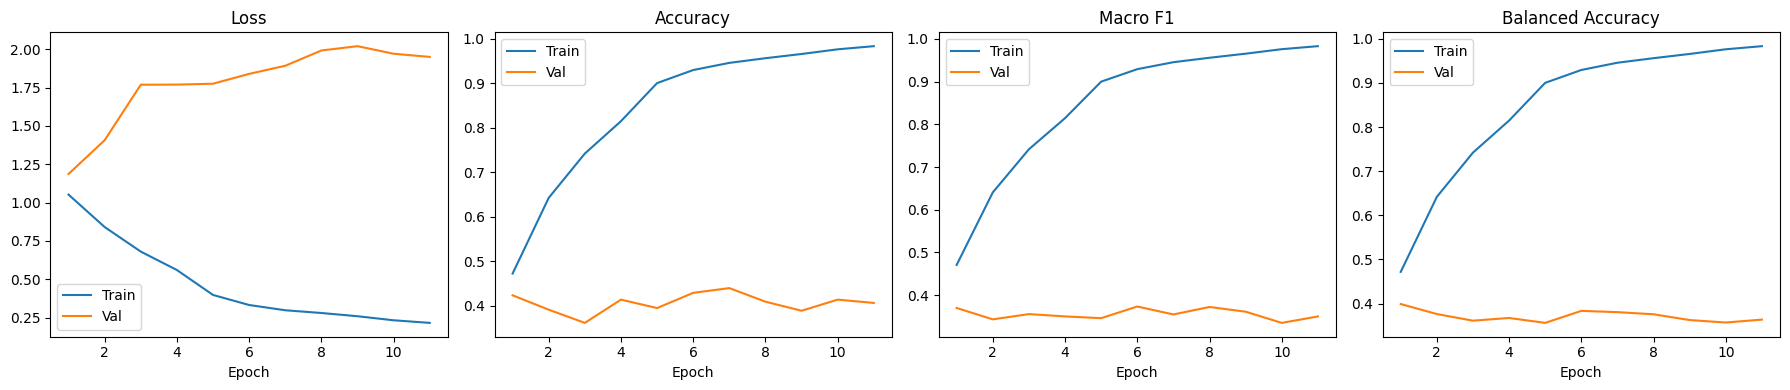

In [35]:
# =========================
# 19) Curves
# =========================
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 4, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 4, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 4, 3)
    plt.plot(epochs, history["train_macro_f1"], label="Train")
    plt.plot(epochs, history["val_macro_f1"], label="Val")
    plt.title("Macro F1")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 4, 4)
    plt.plot(epochs, history["train_bal_acc"], label="Train")
    plt.plot(epochs, history["val_bal_acc"], label="Val")
    plt.title("Balanced Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [36]:
# =========================
# 20) Evaluation helpers
# =========================
@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    logits_all, y_true, y_pred = [], [], []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        logits_all.append(outputs.detach().cpu())
        y_true.extend(targets.numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    logits_all = torch.cat(logits_all, dim=0)
    return logits_all, y_true, y_pred

def show_confusion_and_report(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Validation metrics: {'accuracy': 0.4289680703378066, 'macro_f1': 0.3737363872008241, 'balanced_accuracy': np.float64(0.38400007380472784)}


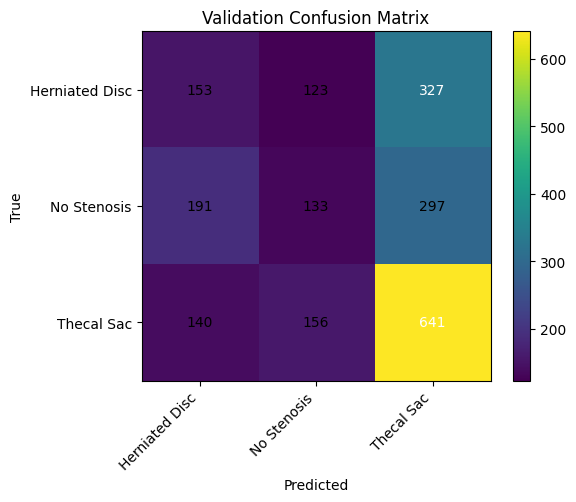

                precision    recall  f1-score   support

Herniated Disc     0.3161    0.2537    0.2815       603
   No Stenosis     0.3228    0.2142    0.2575       621
    Thecal Sac     0.5067    0.6841    0.5822       937

      accuracy                         0.4290      2161
     macro avg     0.3819    0.3840    0.3737      2161
  weighted avg     0.4007    0.4290    0.4050      2161



In [37]:
# =========================
# 21) Validation evaluation
# =========================
val_logits, y_true_val, y_pred_val = predict_loader(model, val_loader, cfg.DEVICE)
val_metrics = compute_metrics(y_true_val, y_pred_val)

print("Validation metrics:", val_metrics)
show_confusion_and_report(
    y_true_val,
    y_pred_val,
    CLASS_NAMES,
    title="Validation Confusion Matrix"
)

Test metrics: {'accuracy': 0.33820306793279764, 'macro_f1': 0.30077734073875384, 'balanced_accuracy': np.float64(0.5556430872313077)}


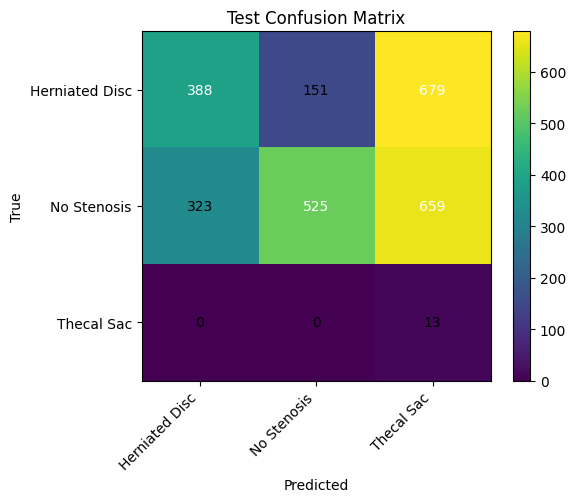

                precision    recall  f1-score   support

Herniated Disc     0.5457    0.3186    0.4023      1218
   No Stenosis     0.7766    0.3484    0.4810      1507
    Thecal Sac     0.0096    1.0000    0.0191        13

      accuracy                         0.3382      2738
     macro avg     0.4440    0.5556    0.3008      2738
  weighted avg     0.6703    0.3382    0.4438      2738



In [38]:
# =========================
# 22) Test evaluation
# =========================
test_logits, y_true_test, y_pred_test = predict_loader(model, test_loader, cfg.DEVICE)
test_metrics = compute_metrics(y_true_test, y_pred_test)

print("Test metrics:", test_metrics)
show_confusion_and_report(
    y_true_test,
    y_pred_test,
    CLASS_NAMES,
    title="Test Confusion Matrix"
)

In [39]:
# =========================
# 23) Save run summary
# =========================
run_summary = {
    "cfg": asdict(cfg),
    "class_names": CLASS_NAMES,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "class_counts_train": class_counts.tolist(),
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
}
summary_path = os.path.join(cfg.SAVE_DIR, "run_summary.json")
with open(summary_path, "w") as f:
    json.dump(run_summary, f, indent=2)

print(f"Saved run summary -> {summary_path}")

Saved run summary -> ./runs_modular_mri/run_summary.json


## What preprocessing from your diagram is implemented?

Yes:

- **Image Resize**: `Resize((RESIZE_SIZE, RESIZE_SIZE))` then crop to `IMAGE_SIZE`
- **Noise Reduction**: optional `GaussianBlur` or `MedianFilter`
- **Standardized Pixel Intensity Ranges**: percentile clipping + `zscore` or `minmax`
- **Data Augmentation**: random resized crop, rotation, affine transform, brightness/contrast jitter, random erasing

## Is regularization included?

Yes. This notebook includes:

- data augmentation
- dropout in the classifier head
- weight decay via `AdamW`
- label smoothing
- random erasing
- optional MixUp
- early stopping
- optional backbone freezing for transfer learning

## Recommended first experiments

Start with:

```python
cfg.MODEL_FAMILY = "resnet"
cfg.MODEL_NAME = "resnet34"
cfg.USE_WEIGHTED_SAMPLER = True
cfg.LOSS_NAME = "ce"
cfg.USE_CLASS_WEIGHTS_IN_LOSS = False
cfg.USE_MIXUP = False
```

Then compare:

1. weighted sampler + CE
2. no sampler + weighted CE
3. focal loss
4. EfficientNet
5. ViT or Swin only after the CNN baselines are stable

## Important note

If you later get **patient IDs or study IDs**, replace the blocked split with a **group split**. That is the most important validation improvement for medical imaging.